<a href="https://colab.research.google.com/github/Milan-Choudhary/ObjectDetection/blob/main/ObjectDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Object2.jpg to Object2.jpg


In [2]:
from transformers import pipeline

detector = pipeline("object-detection", model="facebook/detr-resnet-50")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


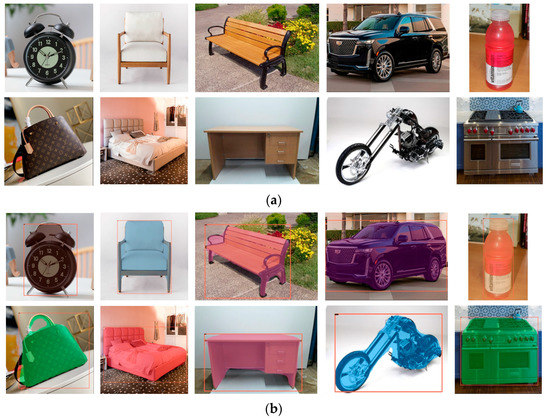

In [3]:
from PIL import Image

image_path = list(uploaded.keys())[0]
image = Image.open(image_path)
image

In [4]:
results = detector(image)
results

[{'score': 0.9945230484008789,
  'label': 'bench',
  'box': {'xmin': 205, 'ymin': 225, 'xmax': 291, 'ymax': 297}},
 {'score': 0.9804114103317261,
  'label': 'oven',
  'box': {'xmin': 461, 'ymin': 107, 'xmax': 539, 'ymax': 177}},
 {'score': 0.9893856048583984,
  'label': 'clock',
  'box': {'xmin': 28, 'ymin': 34, 'xmax': 67, 'ymax': 76}},
 {'score': 0.9788447022438049,
  'label': 'chair',
  'box': {'xmin': 116, 'ymin': 221, 'xmax': 172, 'ymax': 292}},
 {'score': 0.7341405749320984,
  'label': 'bed',
  'box': {'xmin': 99, 'ymin': 110, 'xmax': 184, 'ymax': 175}},
 {'score': 0.9843995571136475,
  'label': 'bottle',
  'box': {'xmin': 484, 'ymin': 9, 'xmax': 514, 'ymax': 87}},
 {'score': 0.9871448874473572,
  'label': 'car',
  'box': {'xmin': 328, 'ymin': 11, 'xmax': 447, 'ymax': 82}},
 {'score': 0.9815492033958435,
  'label': 'bed',
  'box': {'xmin': 103, 'ymin': 326, 'xmax': 184, 'ymax': 384}},
 {'score': 0.8448830246925354,
  'label': 'bed',
  'box': {'xmin': 107, 'ymin': 123, 'xmax': 183

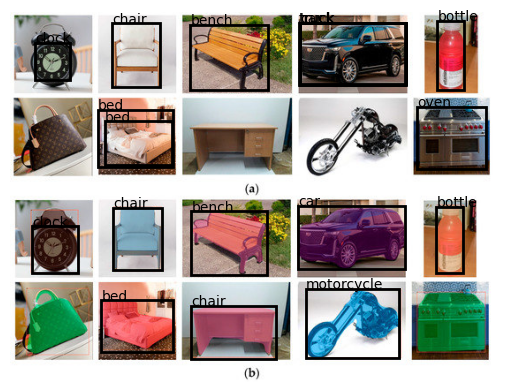

In [5]:
import matplotlib.pyplot as plt

plt.imshow(image)
ax = plt.gca()

for obj in results:
    box = obj['box']

    rect = plt.Rectangle(
        (box['xmin'], box['ymin']),
        box['xmax'] - box['xmin'],
        box['ymax'] - box['ymin'],
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)
    ax.text(box['xmin'], box['ymin'], obj['label'])

plt.axis('off')
plt.show()

In [6]:
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.2
    Uninstalling click-8.3.2:
      Successfully uninstalled click-8.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [7]:
from gtts import gTTS
from IPython.display import Audio, display

# Extract unique labels from the detected objects
detected_labels = [obj['label'] for obj in results]
unique_labels = list(set(detected_labels))

if unique_labels:
    text_to_speak = "Detected objects are: " + ", ".join(unique_labels) + "."
else:
    text_to_speak = "No objects were detected."

print(text_to_speak)

# Convert text to speech
tts = gTTS(text=text_to_speak, lang='en')
tts.save("detected_objects.mp3")

# Play the audio
display(Audio("detected_objects.mp3", autoplay=True))

Detected objects are: bottle, clock, car, truck, oven, bed, motorcycle, bench, chair.
